<a href="https://colab.research.google.com/github/boradedeepak/ML_Models_trained/blob/main/K_Neighbors_classification_(K_NN)_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


Import dataset

In [40]:
df = pd.read_csv('/content/knn_training_dataset.csv')
x = df.iloc[:, :].values
# print(x)

Using Elbow method to find the optimal number of clusters

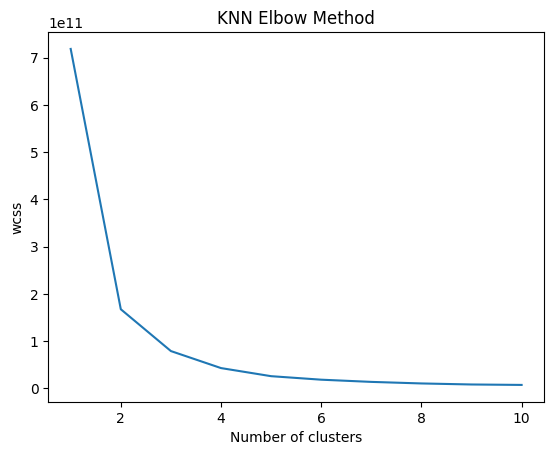

In [41]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42, n_init='auto')
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('KNN Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('wcss')
plt.show()

Training the k-means model on the dataset

In [42]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42, n_init='auto')
y_kmeans = kmeans.fit_predict(x)

print(y_kmeans)

[1 1 3 2 1 1 3 1 0 2 1 1 0 0 1 2 3 3 0 2 2 2 3 1 2 3 0 2 0 3 2 2 2 0 1 1 1
 3 2 3 3 0 3 2 0 0 0 3 2 0 3 1 1 1 1 1 1 2 3 2 0 2 1 3 3 1 3 2 3 1 1 2 1 2
 0 1 2 2 0 3 0 2 0 2 0 3 3 2 3 2 2 1 1 0 0 3 2 3 3 2 3 0 2 1 2 0 1 2 3 1 0
 2 3 3 2 2 2 0 2 1 0 0 1 2 1 1 0 0 1 0 1 0 1 0 3 2 3 0 1 0 3 0 0 0 1 3 2 2
 0 3 3 1 3 2 2 0 2 3 0 1 3 0 2 1 3 2 3 2 3 2 0 1 2 3 0 0 0 3 3 0 1 3 2 1 3
 2 2 0 3 3 0 2 3 2 2 3 1 3 3 3 1 2 2 3 2 0 1 1 3 2 0 2 3 0 3 3 1 0 3 3 1 3
 3 0 0 1 3 0 2 2 0 2 2 0 1 2 1 1 3 2 0 1 3 3 3 3 2 1 3 1 3 2 1 1 2 2 0 0 2
 1 1 1 1 2 2 3 2 0 3 1 1 1 1 3 1 2 3 0 0 3 0 1 0 1 2 2 1 2 0 0 1 3 1 0 2 3
 2 3 2 2 0 2 2 2 2 2 1 1 3 1 0 0 3 0 3 0 0 0 3 3 3 3 3 2 1 0 2 0 0 0 0 0 0
 1 2 3 0 0 1 3 3 0 1 1 2 1 3 1 3 1 2 1 3 0 3 0 0 2 2 0 1 3 0 2 2 1 0 2 0 2
 0 2 0 0 0 0 3 2 1 3 2 3 3 1 0 2 0 1 1 3 3 3 2 2 0 0 0 2 0 1 1 0 0 3 0 2 2
 0 2 1 1 1 2 3 1 0 2 2 1 0 1 3 3 3 3 3 0 0 0 3 2 0 1 1 1 0 3 0 1 2 1 0 2 1
 0 3 0 1 2 3 1 3 2 2 0 0 3 1 2 2 3 1 3 1 1 0 2 3 2 3 2 1 3 3 1 1 0 0 3 2 2
 3 3 3 1 1 0 0 3 3 0 2 3 

Visualising the clusters

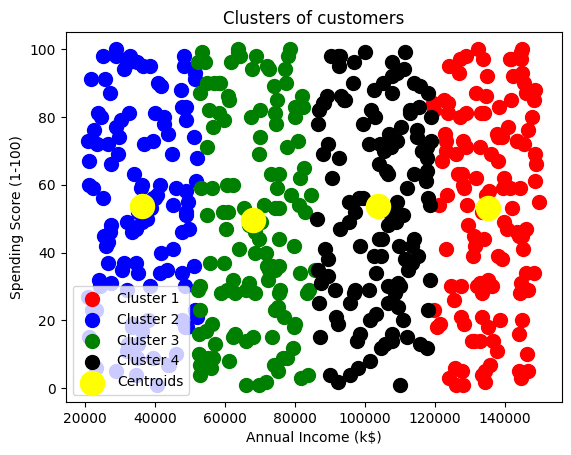

In [43]:
plt.scatter(x[y_kmeans == 0, 1], x[y_kmeans == 0, 2], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(x[y_kmeans == 1, 1], x[y_kmeans == 1, 2], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(x[y_kmeans == 2, 1], x[y_kmeans == 2, 2], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(x[y_kmeans == 3, 1], x[y_kmeans == 3, 2], s = 100, c = 'black', label = 'Cluster 4')
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [44]:
# from sklearn.preprocessing import StandardScaler
# sc = StandardScaler()
# x = sc.fit_transform(x)

In [45]:
# from sklearn.neighbors import KNeighborsClassifier
# y = df.iloc[:, -1].values
# classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
# classifier.fit(x, y)